# Projeto de Machine Learning: Previsão de Risco de Crédito
**Modelos Avaliados:** K-Nearest Neighbors (KNN) vs. Árvore de Decisão (Decision Tree)  
**Disciplina:** Machine Learning e Visão Computacional — projeto  
**Objetivo de Negócio:** Classificar a propensão à inadimplência (`loan_status`: 0 = em dia, 1 = inadimplente) em concessões de crédito pessoal, minimizando perdas financeiras decorrentes de inadimplência (Falsos Negativos) e atrito/lucro cessante de clientes elegíveis (Falsos Positivos).


## 1. Verificação de Integridade dos Dados Originais
Garantia de que os conjuntos de dados fornecidos (`credit_risk_dataset.csv` e `E Commerce Dataset - E Comm.csv`) foram mantidos 100% inalterados através de seus hashes SHA-256.


In [1]:
from pathlib import Path
import hashlib, json
import pandas as pd
import numpy as np
from IPython.display import display, SVG, Image

RAIZ = Path.cwd()
if not (RAIZ / 'credit_risk_dataset.csv').exists():
    RAIZ = RAIZ.parent

hashes = json.loads((RAIZ / 'documentacao/integridade_originais.json').read_text())
for nome, esperado in hashes.items():
    obtido = hashlib.sha256((RAIZ / nome).read_bytes()).hexdigest()
    assert obtido == esperado, f"Hash divergente para {nome}"
    print(f"✔ Integridade confirmada para {nome} (SHA-256: {obtido[:16]}...)")


✔ Integridade confirmada para E Commerce Dataset - E Comm.csv (SHA-256: 3341cb35ac6c76a8...)
✔ Integridade confirmada para credit_risk_dataset.csv (SHA-256: ce3c6d2167717bf1...)


## 2. Análise Exploratória de Dados (EDA)
Inspeção dos dados originais: distribuição da classe alvo, assimetria de renda, taxa de juros e correlação de Pearson.


Total de registros: 32,581
Total de colunas: 12
Distribuição do alvo (loan_status):
loan_status
0    78.18
1    21.82
Name: proportion, dtype: float64%

Gráficos gerados durante a EDA:


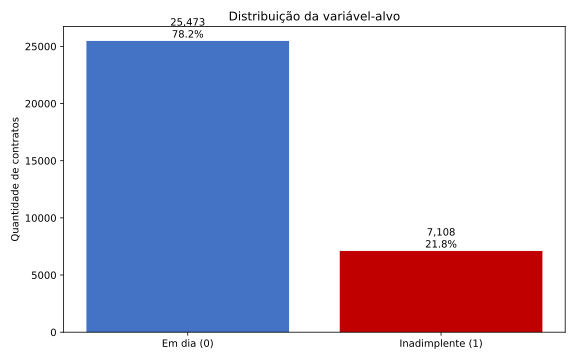

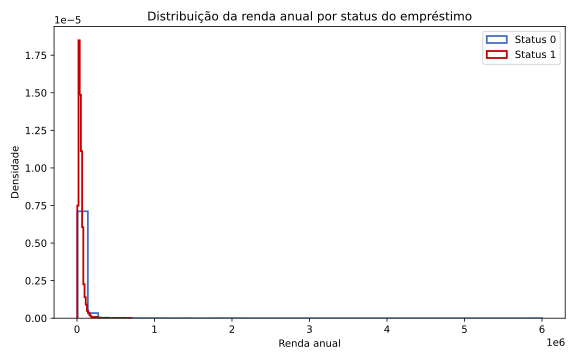

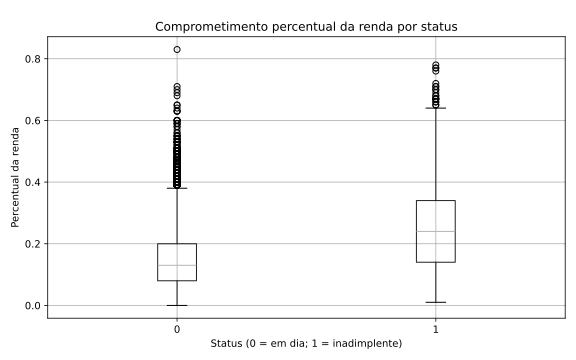

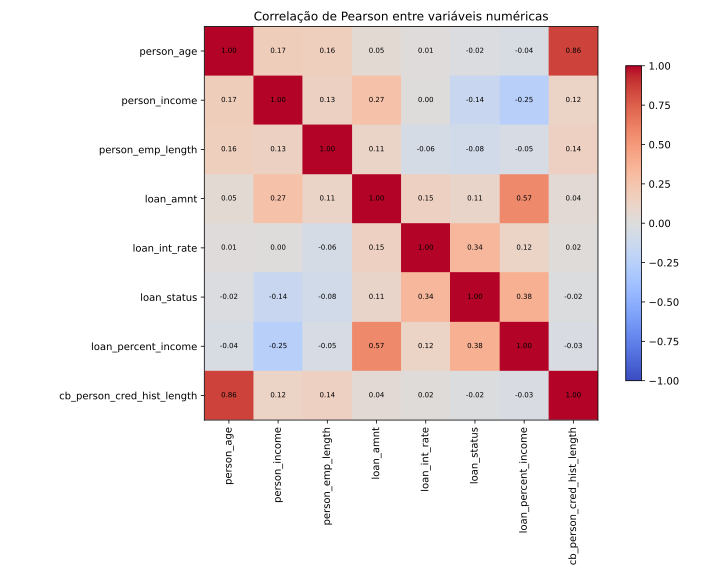

In [2]:
dados_originais = pd.read_csv(RAIZ / 'credit_risk_dataset.csv')
print(f"Total de registros: {len(dados_originais):,}")
print(f"Total de colunas: {dados_originais.shape[1]}")
print(f"Distribuição do alvo (loan_status):\n{dados_originais['loan_status'].value_counts(normalize=True).round(4) * 100}%")

print("\nGráficos gerados durante a EDA:")
display(SVG(filename=str(RAIZ / 'resultados/graficos_eda/01_distribuicao_alvo.svg')))
display(SVG(filename=str(RAIZ / 'resultados/graficos_eda/02_histograma_renda_status.svg')))
display(SVG(filename=str(RAIZ / 'resultados/graficos_eda/03_boxplot_comprometimento.svg')))
display(SVG(filename=str(RAIZ / 'resultados/graficos_eda/04_correlacao_pearson.svg')))


## 3. Limpeza, Consistência e Engenharia de Atributos
- Remoção de 165 duplicatas;
- Exclusão de 5 registros com idade anômala (>100 anos);
- Tratamento de inconsistência (`tempo de emprego >= idade`) convertida em nulo para imputação;
- Criação da feature definido `comprometimento_renda = (loan_amnt / person_income) * 100` com proteção contra divisão por zero;
- Descarte de `loan_percent_income` para evitar colinearidade estrita.


In [3]:
dados_prep = pd.read_csv(RAIZ / 'dados_derivados/credito_com_feature.csv')
print(f"Base após limpeza e feature engineering: {dados_prep.shape[0]:,} linhas, {dados_prep.shape[1]} colunas.")
display(dados_prep[['loan_amnt', 'person_income', 'comprometimento_renda', 'loan_status']].head())


Base após limpeza e feature engineering: 32,411 linhas, 13 colunas.


,loan_amnt,person_income,comprometimento_renda,loan_status
0,35000,59000,59.322034,1
1,1000,9600,10.416667,0
2,5500,9600,57.291667,1
3,35000,65500,53.435115,1
4,35000,54400,64.338235,1


## 4. Otimização dos Modelos e Diagnóstico de Overfitting
Validação cruzada em 5 dobras estratificadas sem vazamento de dados:
- Imputação por mediana, balanceamento por oversampling e escalonamento (`StandardScaler`) calculados estritamente na partição de treino de cada dobra;
- Comparação do F1-score no Treino vs. Validação para identificar memorização.


,model,param,cv_f1,cv_std
0,KNN,3.0,0.635808,0.012214
1,KNN,5.0,0.624339,0.010335
2,KNN,7.0,0.626039,0.011015
3,KNN,9.0,0.631870,0.008257
4,Tree,3.0,0.706022,0.009311
5,Tree,5.0,0.732909,0.007154
6,Tree,7.0,0.755164,0.011838
7,Tree,NaN,0.749097,0.004188



Curvas de Otimização e Diagnóstico de Overfitting:


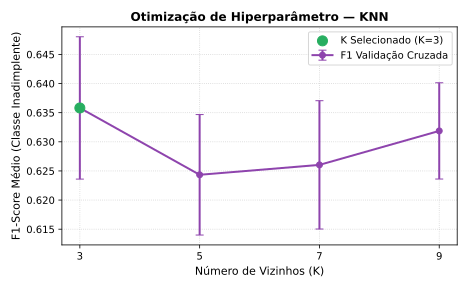

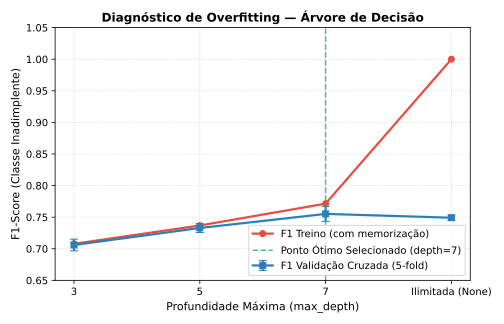

In [4]:
cv_res = pd.read_csv(RAIZ / 'resultados/validacao_corrigida.csv')
display(cv_res)

print("\nCurvas de Otimização e Diagnóstico de Overfitting:")
display(SVG(filename=str(RAIZ / 'resultados/avaliacao_final/curva_validacao_knn.svg')))
display(SVG(filename=str(RAIZ / 'resultados/avaliacao_final/curva_overfitting_arvore.svg')))


## 5. Explicabilidade: Importância das Variáveis (Feature Importance)
Avaliação dos pesos atribuídos pela Árvore de Decisão (`max_depth=7`) às variáveis preditoras.


Top 5 variáveis mais determinantes:


,feature,importance
25,comprometimento_renda,0.316995
24,loan_int_rate,0.269129
23,person_income,0.144884
22,person_home_ownership_RENT,0.063378
21,loan_grade_D,0.052397


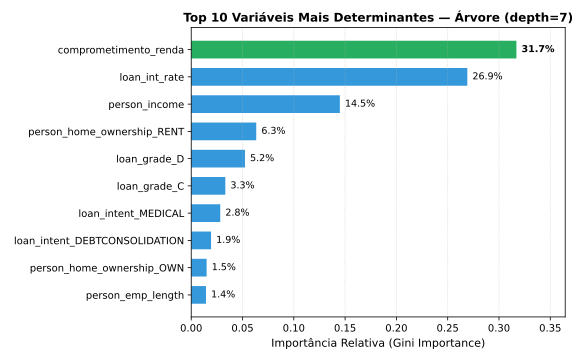

In [5]:
fi_df = pd.read_csv(RAIZ / 'resultados/avaliacao_final/feature_importance_arvore.csv')
print("Top 5 variáveis mais determinantes:")
display(fi_df.sort_values(by='importance', ascending=False).head(5))

display(SVG(filename=str(RAIZ / 'resultados/avaliacao_final/feature_importance_arvore.svg')))


## 6. Desempenho no Conjunto de Teste (6.483 contratos)
Avaliação dos modelos finais no teste original (sem balanceamento), preservando a proporção real de inadimplência (21,87%).


,modelo,acuracia,precisao_1,recall_1,f1_1,falsos_positivos,falsos_negativos
0,knn_k3,0.824927,0.578830,0.732722,0.646748,756,379
1,arvore_depth7,0.884004,0.720822,0.766573,0.742994,421,331



Matrizes de Confusão no Teste:


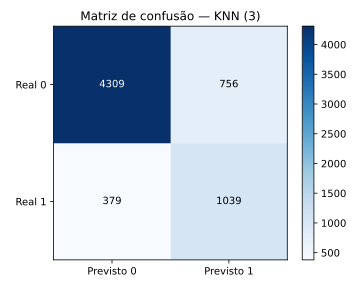

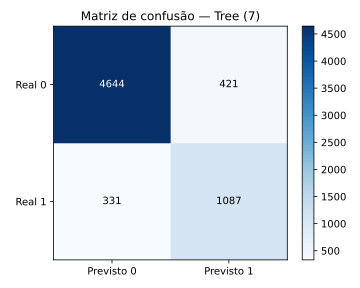

In [6]:
comp_final = pd.read_csv(RAIZ / 'resultados/avaliacao_final/comparacao_final.csv')
display(comp_final)

print("\nMatrizes de Confusão no Teste:")
display(SVG(filename=str(RAIZ / 'resultados/avaliacao_final/knn_k3_matriz_confusao.svg')))
display(SVG(filename=str(RAIZ / 'resultados/avaliacao_final/arvore_depth7_matriz_confusao.svg')))


## 7. Simulação de Impacto Financeiro (P&L) e Veredito de Negócio
- **Falso Negativo (FN):** Perda de principal estimada em R$ 5.000,00 por cliente inadimplente não identificado.
- **Falso Positivo (FP):** Lucro cessante (margem financeira líquida) estimado em R$ 1.000,00 por bom cliente indevidamente recusado.


,Modelo,Falsos Positivos,Falsos Negativos,Custo FP (R$),Custo FN (R$),Custo Total (R$)
0,KNN (K=3),756,379,756000,1895000,2651000
1,Árvore (depth=7),421,331,421000,1655000,2076000


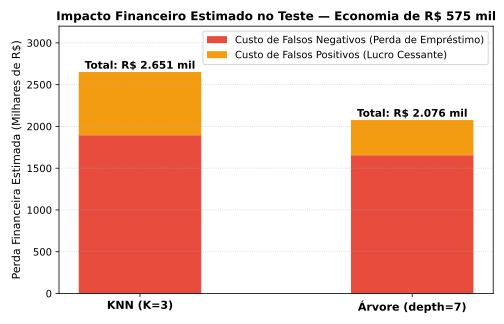

In [7]:
sim_df = pd.read_csv(RAIZ / 'resultados/avaliacao_final/simulacao_financeira_custos.csv')
display(sim_df)

display(SVG(filename=str(RAIZ / 'resultados/avaliacao_final/simulacao_financeira_custos.svg')))
